#  Support Vector Machine: Métodos con Kernel 

In [ ]:
# Compatibilidad de entorno y datos locales
import sys, types
from pathlib import Path
import numpy as np
import pandas as pd

# Compatibilidad para sklearn.datasets.samples_generator
try:
    import sklearn.datasets as _ds
    _mod = types.ModuleType("sklearn.datasets.samples_generator")
    _mod.make_blobs = _ds.make_blobs
    _mod.make_circles = _ds.make_circles
    sys.modules.setdefault("sklearn.datasets.samples_generator", _mod)
except Exception:
    pass

# Compatibilidad para keras.utils.np_utils
try:
    from tensorflow.keras.utils import to_categorical as _to_categorical
    _km = types.ModuleType("keras.utils.np_utils")
    _km.to_categorical = _to_categorical
    sys.modules.setdefault("keras.utils.np_utils", _km)
except Exception:
    pass

# Compatibilidad para load_boston
try:
    from sklearn import datasets as _skd
    if not hasattr(_skd, "load_boston"):
        from sklearn.datasets import load_diabetes
        from sklearn.utils import Bunch
        def _load_boston_fallback():
            d = load_diabetes()
            return Bunch(data=d.data, target=d.target, feature_names=d.feature_names, DESCR="Fallback load_boston")
        _skd.load_boston = _load_boston_fallback
except Exception:
    pass


Recordemos que el Support Vector Machine intenta maximizar la distancia entre dos clases de puntos.

Lo que se genera es un hiperplano (a través de una linea en un espacio de N dimensiones). Lo que se hace es generar **dos support hyperplanes** paralelos y se pone el optimo en medio de él. Estos dos hyperpalnos se ajustan en los puntos más extremos de las clases y se llaman **support vectors**. El hyperplano óptimo se llma **maximum Margin Hyperplane**, la distancia entre los dos hyperplanos de llama **margin** 

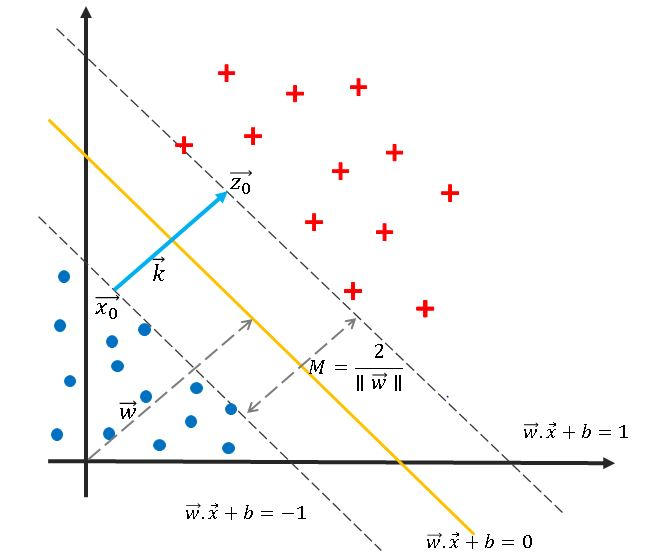

Lo que queremos es maximizar el Margin que se traduce, luego de matemáticas a:

$$
\min \left(\frac{1}{2}\|\vec{w}\|^{2}\right)
$$

Pero tenemos la condición de que ningún punto debe estar en medio de los dos **support hyperplanes** esto setraduce a:
$$
y_{i}\left(\vec{w} \cdot \vec{x}_{i}+b\right) \geq 1, \forall \text { Points } i=1, \ldots, \text { to } \ldots, n
$$


Esto último es algo restrictivo. Si queremos añadir una tolerancia $\xi_i$ (**soft margin vector machine**) , el problema queda:
\begin{align*}
&   \min_{w \in \mathbb R^d,\, b \in \mathbb R,\,  \xi \in   \mathbb R^n}   \quad \frac 12 \| w\|^2     +  C \sum_{i=1}^n  \xi_i  \\ 
&  \mbox{subject to}  \quad    y_i (\langle w,x_i \rangle   + b)   \geq 1 - \xi_i    \quad \mbox{ and } \quad   \xi_i \geq 0  , \,    \,  i = \dots n 
\end{align*}

donde $C$ es una penalización y la función pérdida puede ser de otra forma en realida. Lo habitual es que sea la suma, pero puede ser la suma de los cuadrados....

Nota: **Do SVMs use Gradient Descent to find the minima? No way! (Most people fail to know this). The minima is directly found by solving derivatives of the Objective function. Since there are constraints, we’ll need to first take the Langrangian of the Objective Function to solve for the minima**

Vemos que $\langle w,x_i \rangle  + b$ implica indieractamente que los planos son lienales. Estos no es siempre cierto. Usaremos luego los **kernels** para quitar este problema. Estos son para transformar el espacio  y parsarlo a uno nuevo donde el hiperplano si sea lineal:
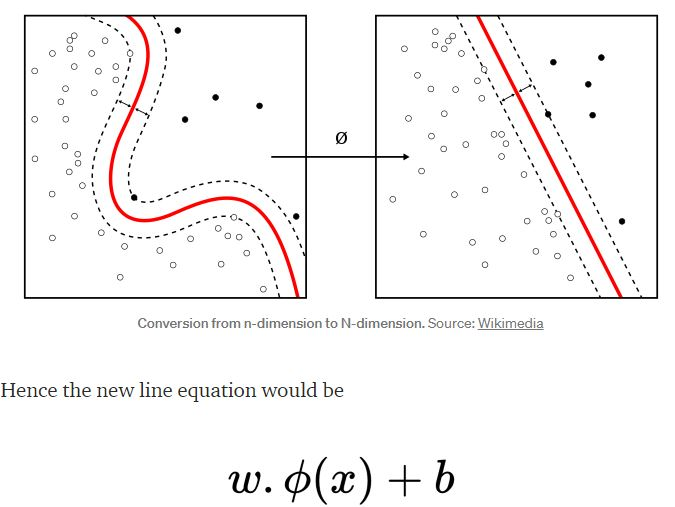

Los Kernels más utilizados son:
Gaussian Radial Basis Function (RBF):
$$
\phi(x, y)=\exp \left(-\gamma\left\|x_{i}-x_{j}\right\|^{2}\right)
$$
where $\gamma>0$
A special case is $(\gamma=1 / 2) \sigma^{2}$
Gaussian Kernel:
$$
\phi(x, y)=\exp \left(-\frac{\|x-y\|^{2}}{2 \sigma^{2}}\right)
$$
Polynomial Kernel:
$$
k\left(x_{i}, x_{j}\right)=\left(x_{i} \cdot x_{j}+1\right)^{d}
$$
- Sigmoid kernel:
$$
k(x, y)=\tanh \left(\alpha \cdot x^{T} y+c\right)
$$

## Dual problem para el caso no soft
$$
L(w, b, \alpha)=\frac{1}{2} w^{2}-\sum_{i=1}^{n} \alpha_{i} \cdot\left[y_{i}\left(w \cdot x_{i}+b\right)-1\right] \quad, \alpha_{i} \geq 0 \quad (5)
$$ 
Condiciones necesarias:
$$
\begin{array}{c}
\frac{\partial L}{\partial w}=0 \\
\Rightarrow w-\sum_{i=1}^{n} \alpha_{i} \cdot y_{i} \cdot x_{i}=0 \\
\therefore \quad w=\sum_{i=1}^{n} \alpha_{i} \cdot y_{i} \cdot x_{i} \quad(6) \\
\& \quad \frac{\partial L}{\partial b}=-\sum_{i=1}^{n} \alpha_{i} \cdot y_{i}=0 \quad(7)
\end{array}
$$
Expandiendo (5):
$$
\begin{array}{r}
\frac{1}{2} w^{2}-\sum_{i=1}^{n}\left[\alpha_{i} \cdot\left(y_{i} \cdot w \cdot x_{i}+y_{i} \cdot b\right)-\alpha_{i}\right] \\
\Rightarrow \frac{1}{2} w^{2}-\sum_{i=1}^{n}\left[\alpha_{i} \cdot y_{i} \cdot w \cdot x_{i}+\alpha_{i} \cdot y_{i} \cdot b-\alpha_{i}\right] \\
\Rightarrow \frac{1}{2} w^{2}-\sum_{i=1}^{n} \alpha_{i} \cdot y_{i} \cdot w \cdot x_{i}-\sum_{i=1}^{n} \alpha_{i} \cdot y_{i} \cdot b+\sum_{i=1}^{n} \alpha_{i}
\end{array}
$$
Sustiyendo en (6) y (7)
$$
\begin{aligned}
& \frac{1}{2} w^{2}-w^{2}+\sum_{i=1}^{n} \alpha_{i} \\
\Rightarrow &-\frac{1}{2} w^{2}+\sum_{i=1}^{n} \alpha_{i} \\
\therefore & \sum_{i=1}^{n} \alpha_{i}-\frac{1}{2} w^{2}
\end{aligned}
$$

Resustituimos en 6 y llegamos a:
$$
W(\Lambda)=\sum_{i=1}^{n} \alpha_{i}-\frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_{i} \alpha_{j} y_{i} y_{j}\left(x_{i} \cdot x_{j}\right)
$$

este es el funcional y esta representados sólo en función de $\alpha_{i}; \: i=1,...,n$ y le llamamos $\Lambda$

## Importación de los módulos

In [ ]:
%matplotlib inline
from pylab import *
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split


## Support Vector Machine con Kernel Lineal

In [ ]:
## generar dos grupos clusters con una desviación estandar de 0.6

X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y);

Estos datos son muy fáciles de separa, sobretodo con un separador lineal. Por ejemplo. la curva y = 0.6 x + 1.6 sperar perfectamente las dos categorias de puntos.
> Comprobémoslo

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



Recordamos que el problema (primal) del SVM es:

\begin{align*}
&   \min_{w \in \mathbb R^d,\, b \in \mathbb R,\,  \xi \in   \mathbb R^n}   \quad \frac 12 \| w\|^2     +  C \sum_{i=1}^n  \xi_i  \\ 
&  \mbox{subject to}  \quad    y_i (\langle w,x_i \rangle   + b)   \geq 1 - \xi_i    \quad \mbox{ and } \quad   \xi_i \geq 0  , \,    \,  i = \dots n 
\end{align*}


> Por qué es conveniente en este caso de elegir la constante $C$ muy grande para este problema?

Utilicemos la función Python  **SVC** con un kernel lineal con un valor de $C$ elevado

In [ ]:
from sklearn.svm import SVC 
mon_svc = SVC(C=10000000000.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)
mon_svc.fit(X,y)

## veamos cómo nos fue
mon_svc.predict(X)
mon_svc.score(X,y)

Las instrucciones siguientes permiten de mostrar gráficamente lso dos planes marginales que tienen los vectores soporte:
$$ \{ x \, | \,  \langle x ,w \rangle + b  =  1 \} $$
y
$$ \{ x \, | \,  \langle x ,w \rangle + b  = - 1 \}. $$

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



Se peude recuperar los puntos soporte en el atributo **suport_vectors_**
> Mostraremos y sobrepondremos los puntos de soporte a  nuestro scatter

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



## SVM con un kernel no lineal

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



 > Muestre los puntos y trate de ajustarles un clasificador lineal.
 
**ATENCIÓN: si toma un valor de $C$ muy grande limitamos demasiado las variables slack $\xi_i ; ?: i=1,...n$ y no convergeremos** Además aquí los datos no son separables linealmente.


In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: entrena el modelo con fit y luego calcula predicciones con predict.



##### Veámos como nos fue:

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.



Para separa mejor los datos, podemos intentar proyectarlos en un espacio de dimensión 3.
> Creamos una coponente complementaria  $ x_3 =  \|x \|^2$. Verifiquemos gráficamente que ahora se puede separa fácilmente el conjunto de datos en las dos categorías iniciales. 

In [ ]:
X3 = np.array([np.linalg.norm(val)**2 for val in X]);
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(X[:,0],X[:,1],X3, c = y);

> Ajustar un clasificador con Kernel (Rdaiañ Basis Function) con la función SVC con los datos (Esta vez no utilizamos a X3). Muestre los puntos de soporte, las predicciones y las fronteras en la misma gráfica.

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: entrena el modelo con fit y luego calcula predicciones con predict.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



## Soft Margin Support Vector Machine

#### Creémos un conjunto de datos en un scatter difícilmente separable linealmente:

In [ ]:
X, y = make_blobs(n_samples=80, centers=2,
                  random_state=0, cluster_std=0.9)
plt.scatter(X[:, 0], X[:, 1], c=y);

> Ajustaremos y repsentaremos grpaficamente SVM lineales con $C=1$. Compraremos también los hyperplanos marginales para $C=1$ y $C=100$

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



Visualizamos el efecto de $C$ sobre el margen geométrico:

Una vez que cambiamos $C$, cambiamos la solución $$(w^\star,b^\star, \xi^\star)$$ del problema con márgenes flexibles **Soft Margin SVM**. Y entonces cambiamos la regla de decición del algoritmo: $$ x \mapsto  \mbox{sign}(\langle x,w^\star \rangle +b^\star) $$ 

> Elegir $C$ en $[0.001,0.01,0.05,0.1,2,1,10,100,10^3,10^4]$ y evalue el error de generalización para un corte train/test.

In [ ]:
X, y = make_blobs(n_samples=8000, centers=2,
                  random_state=0, cluster_std=1.1)

plt.scatter(X[:,0], X[:,1], c=y) ;

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [ ]:
Cgrid = np.array([0.001,0.01,0.05,0.1,1,2,10,100,1000,10000])

from sklearn.model_selection import train_test_split

C_score= []

for C in Cgrid:
    Mon_SVM_train_test = SVC(C = C, kernel = "linear", gamma = "auto")
    Mon_SVM_train_test.fit(X_train,y_train)
    Xpred = Mon_SVM_train_test.predict(X_train)
    count = 0
    for i in range(Xpred.shape[0]):
        if Xpred[i] == y_train[i] :
            count += 1
    print("Cas C =", str(C), ":",count / Xpred.shape[0])
    C_score.append(Mon_SVM_train_test.score(X_test, y_test))    
print(C_score)

## SVM para el reconocimiento facial

Vamos ahotra  autilizar un clasificador SV, para el problema de reconocimiento de imágenes. Utilizaremos una biblioteca de imágenes etiquetadas de la librería Wild dataset, que está constituída de fotos públicas de famosos. Es posible de cargar estos datos usando **sckit-learn** de la manera que se muestra acontinuación (la primera vez que s ehaga puede tomar unos minutos, se necsita una buena conexión a internet)

In [ ]:
from sklearn.datasets import fetch_lfw_people
#  Guardaremos las imágenes de las personas
# que aperecen al menso  100 veces :
faces = fetch_lfw_people(min_faces_per_person=100) 
print(faces.target_names)

Disponemos de 1140 imágenes de dimensión 62 x 47 (nivel de gris de un pixel = une avriable).
Se trata entonces de un problema de clasificasión muticlase de dimensión 2194 (NO SON 2194 CLASES). Debemos vectorializar cada imagen (flatten) cada imagen: Una observación = 1 vector de talla 2914 en el cual disponemos de niveles de gris de todos los pixles de la imagen.

Para mostrar las imágenes de nuestra base:

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: construye la visualización con etiquetas claras y comenta qué se observa.



> Cuántas clases tiene este problema?

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.



In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.



Reduzca la dimensión a 200

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
Images = SelectKBest(chi2, k=200).fit_transform(images,faces.target)
Images.shape


> Ajustemos un SVM con u  RBF y un SVM lineal en estos datos, evaluar el error de test para $C=0.1$. Tendremos cuidado de quilibrar la perdidad con: **class_veight= balanced** en la función SVC(). Intentar también sin este comando. También mire la matriz de confusión.

### Lineal

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



### Radial Basis Function

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: ajusta el modelo con fit usando los datos de entrenamiento.



#### El resto lo hatremos sólo con el kernel lineal

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: entrena el modelo con fit y luego calcula predicciones con predict.



In [ ]:
### reporte de clasificación
from sklearn.metrics import classification_report
print(classification_report(ytest, y_pred, target_names=faces.target_names))

In [ ]:
### Mtariz de confusión
from sklearn.metrics import confusion_matrix
confusion_matrix(ytest, y_pred)

## Validación cruzada

In [ ]:
## usaremos la función grid

from sklearn.model_selection import GridSearchCV
parameters = {'kernel':('rbf', 'rbf'), 'C':[1, 10]}
svc = SVC(gamma="scale",class_weight='balanced');
clf = GridSearchCV(svc, parameters);
clf.fit(Xtrain, ytrain);
GridSearchCV(estimator=SVC(),param_grid={'C': [1, 10], 'kernel': ('rbf', 'rbf')}); ## 5-fold por defecto

In [ ]:
# TO DO:
# Completa este bloque para continuar el ejercicio guiado.
# Pista: implementa este bloque siguiendo el objetivo descrito en la celda anterior.

